In [17]:
import pickle
import polars as pl
import pandas as pd
import numpy as np
pd.set_option("display.max_columns", None)
#np.set_printoptions(suppress=True, precision=3)
#pd.options.display.float_format = '{:.0f}'.format
import matplotlib.pyplot as plt

## ETS

In [8]:
ets = pd.read_parquet("results/ETS-batch.parquet")
ets.head()

,node,batch,mae,mse,r2,mape,model
0,125960550,0,4.889725,32.341223,-1.230709,0.500413,ETS
1,125960550,1,5.257994,35.007336,-1.572577,0.546295,ETS
2,125960550,2,5.786613,46.518887,-2.265364,0.688294,ETS
3,125960550,3,5.420447,46.464988,-2.073230,0.656523,ETS
4,125960550,4,5.404102,48.147106,-2.655442,0.662021,ETS


In [9]:
ets.shape

(380, 7)

In [10]:
ets["mae"].mean(), ets["mape"].mean(), ets["mse"].mean(), ets["r2"].mean()

(140.70901012028548,
 0.6852637942018918,
 105877.9870150889,
 0.06128230140722971)

In [13]:
with open('results/ETS-targets.pkl', 'rb') as f:
    ets_targets = pickle.load(f)

In [14]:
ets_targets.keys()

dict_keys([53, 365, 382, 666, 701, 1326, 1404, 1569, 1916, 2617])

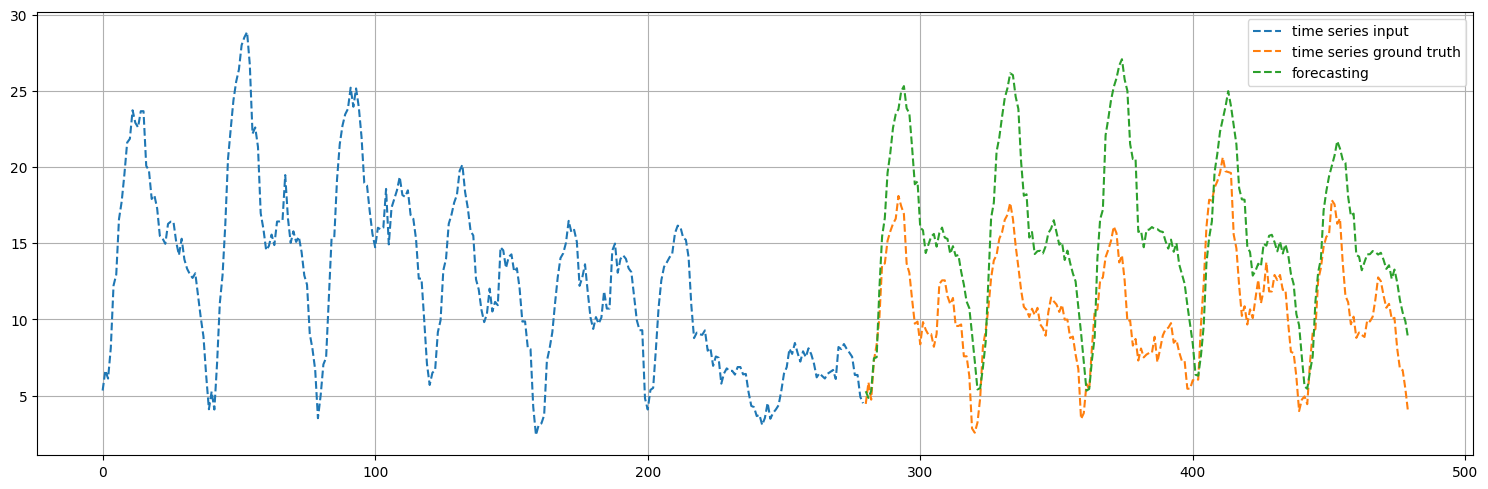

In [18]:
batch_idx = 0
node_ts = ets_targets[53]
forecast_index = range(len(node_ts[batch_idx]["input"]), 
                       len(node_ts[batch_idx]["input"]) + node_ts[batch_idx]["true"].shape[0])

plt.figure(figsize=(15,5))
plt.plot(node_ts[batch_idx]["input"], '--', label="time series input")
plt.plot(forecast_index, node_ts[batch_idx]["true"], '--', label="time series ground truth")
plt.plot(forecast_index, node_ts[batch_idx]["pred"], '--', label="forecasting")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

## Prophet

In [19]:
proph = pd.read_parquet("results/prophet-batch.parquet")
proph.head()

,node,batch,mae,mse,r2,mape,model
0,125960550,0,6.184129,54.194856,-2.738046,0.708893,prophet
1,125960550,1,6.234772,54.744795,-3.023020,0.712944,prophet
2,125960550,2,6.856584,64.557575,-3.531579,0.901209,prophet
3,125960550,3,6.696947,64.544619,-3.269030,0.822222,prophet
4,125960550,4,6.220929,54.074972,-3.105500,0.782420,prophet


In [20]:
proph.shape

(380, 7)

In [21]:
proph["mae"].mean(), proph["mape"].mean(), proph["mse"].mean(), proph["r2"].mean()

(244.18961070042806,
 1.0469632408121237,
 238431.9120207524,
 -1.4164776470875238)

In [24]:
with open('results/prophet-targets.pkl', 'rb') as f:
    ph_targets = pickle.load(f)

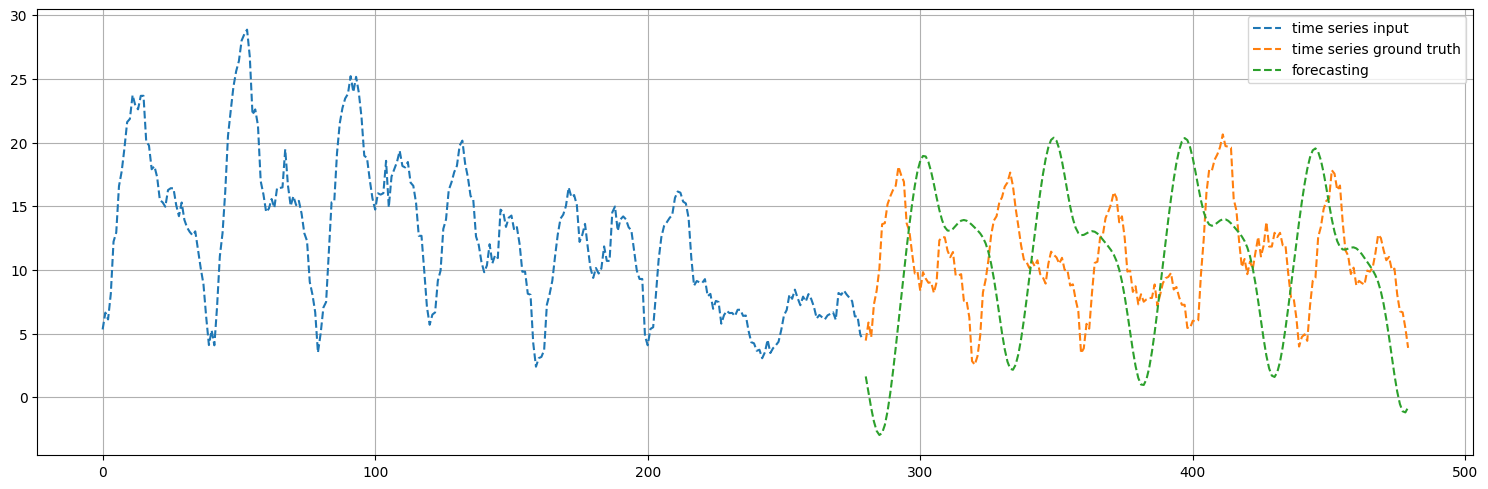

In [25]:
batch_idx = 0
node_ts = ph_targets[53]
forecast_index = range(len(node_ts[batch_idx]["input"]), 
                       len(node_ts[batch_idx]["input"]) + node_ts[batch_idx]["true"].shape[0])

plt.figure(figsize=(15,5))
plt.plot(node_ts[batch_idx]["input"], '--', label="time series input")
plt.plot(forecast_index, node_ts[batch_idx]["true"], '--', label="time series ground truth")
plt.plot(forecast_index, node_ts[batch_idx]["pred"], '--', label="forecasting")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

## SARIMA

In [2]:
sarima = pd.read_parquet("results/sarima-batch.parquet")
sarima

,node,batch,mae,mse,r2,mape
0,125960550,0,10.347068,122.236784,-7.431182,0.944086
1,125960550,1,10.996744,135.814391,-8.980565,1.050288
2,125960550,2,10.407377,124.126579,-7.712988,1.046834
3,125960550,3,9.848582,110.801220,-6.328477,0.940071
4,125960550,4,10.188016,117.117835,-7.891864,0.988669
...,...,...,...,...,...,...
375,47568123,33,122.099164,18529.506844,-4.207897,1.004404
376,47568123,34,134.864332,22125.282199,-4.781296,0.989111
377,47568123,35,154.844988,26676.694033,-9.395470,0.996625
378,47568123,36,149.790391,25897.941344,-7.938702,1.052741


In [3]:
sarima["mae"].mean(), sarima["mape"].mean(), sarima["mse"].mean(), sarima["r2"].mean()

(295.1542481560667, 0.9060360463396424, 352047.63172737433, -3.052604388194399)

## MLP

In [ ]:
mlp = pd.read_parquet("results/MLP-short-time.parquet")
mlp.head()

In [ ]:
np.mean(mlp.mae.values)

In [ ]:
print(f"{mlp['mae'].mean():,.0f}")

In [ ]:
print(f"{mlp['mae'].mean():.0f}")

In [ ]:
valores = (mlp["mae"].mean(), mlp["mape"].mean(), mlp["mse"].mean(), mlp["r2"].mean())
valores

In [ ]:
valores = np.array(valores, dtype=np.float64)

print(valores)

In [ ]:
# Lê o arquivo Parquet
mlp = pl.read_parquet("results/MLP-short-time.parquet")

# Calcula a média de todas as colunas numéricas
# means = mlp.select([
#     pl.col(pl.Float64).mean().round(3).alias(f"{col.name}_mean")
#     for col in mlp.schema.items()
#     if isinstance(col[1], pl.Float64)
# ])

# # Mostra o resultado
# print(means)

In [ ]:
mlp.select([
    pl.col("mae").mean().round(3),
    pl.col("mse").mean().round(3),
    pl.col("r2").mean().round(3),
    pl.col("mape").mean().round(3)
])

In [ ]:
means_dict = mlp.select([
    pl.col("mae").mean(),
    pl.col("mse").mean(),
    pl.col("r2").mean(),
    pl.col("mape").mean()
]).to_dict(as_series=False)

# Formatando e imprimindo sem notação científica
for k, v in means_dict.items():
    print(f"{k}: {v[0]:,.3f}")

## LSTM

In [ ]:
lstm = pd.read_parquet("results/LSTM-short-time.parquet")
lstm.head()

In [ ]:
lstm["mae"].mean(), lstm["mape"].mean(), lstm["mse"].mean(), lstm["r2"].mean()

## GRU

In [ ]:
gru = pd.read_parquet("results/GRU-short-time.parquet")
gru.head()

In [ ]:
gru["mae"].mean(), gru["mape"].mean(), gru["mse"].mean(), gru["r2"].mean()

## Chronos Base

In [ ]:
cbase = pd.read_parquet("results")
cbase.head()

## Chronos Small

In [5]:
csmall = pd.read_parquet("results/cronos-chronos-t5-small-batch.parquet")
csmall.head()

,node,batch,mae,mse,r2,mape,model
0,125960550,0,4.751236,36.435028,-1.513076,0.466158,chronos-t5-small
1,125960550,1,3.825767,21.288189,-0.564401,0.387753,chronos-t5-small
2,125960550,2,3.145729,15.849104,-0.112518,0.355886,chronos-t5-small
3,125960550,3,4.818396,36.318985,-1.402165,0.474547,chronos-t5-small
4,125960550,4,3.977620,24.267214,-0.842425,0.538362,chronos-t5-small


In [7]:
csmall.shape

(38, 7)

In [6]:
csmall["mae"].mean(), csmall["mape"].mean(), csmall["mse"].mean(), csmall["r2"].mean()

(5.368557867250945, 0.5650375414835779, 47.90619797455637, -0.9573767687145033)